# Teleportation Protocol

# Project 3: Quantum Teleportation
**Objective:** Move a quantum state $|\psi\rangle$ between qubits using a shared Bell pair and classical bit communication.

**Theory:**
Because of the No-Cloning Theorem, we cannot physically copy a quantum state. Teleportation destroys the original state on Alice's side and reconstructs it on Bob's side using dynamic, classically-controlled quantum gates.

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
import numpy as np
from IPython.display import display

In [2]:
# We need 3 quantum wires and 3 classical wires for measurement
qr = QuantumRegister(3, name="q")

# We separate the classical registers so we can easily dynamically control Bob's gates
crz = ClassicalRegister(1, name="crz") # Alice's measurement of the message
crx = ClassicalRegister(1, name="crx") # Alice's measurement of her Bell half
crb = ClassicalRegister(1, name="bob_val") # Bob's final verification measurement

qc = QuantumCircuit(qr, crz, crx, crb)

print("Registers configured successfully.")

Registers configured successfully.


In [3]:
# 1. Create a distinct, unknown state for Alice to teleport
# Let's rotate Qubit 0 by Pi/4 so it's not just a standard 0 or 1
qc.rx(np.pi/4, 0)
qc.barrier()

# 2. Create the shared Bell State between Alice (Qubit 1) and Bob (Qubit 2)
qc.h(1)
qc.cx(1, 2)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

In [4]:
# 3. Alice entangles her message (Qubit 0) with her Bell half (Qubit 1)
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# 4. Alice measures her qubits and stores them in the specific classical registers
qc.measure(0, crz)
qc.measure(1, crx)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>), clbits=())

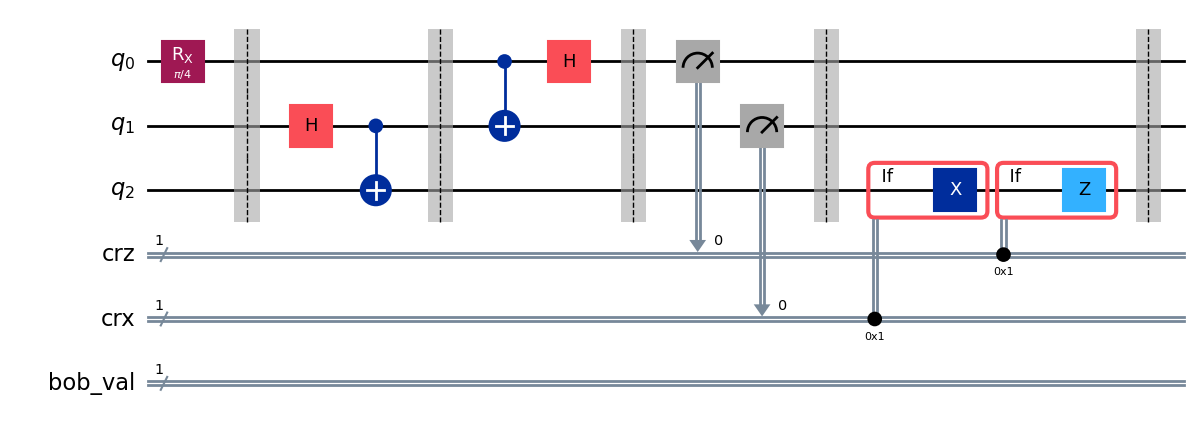

In [5]:
# 5. Bob applies X and/or Z gates depending on what Alice measured.
# In modern Qiskit, we use the if_test context manager for dynamic circuits.
with qc.if_test((crx, 1)):
    qc.x(2)

with qc.if_test((crz, 1)):
    qc.z(2)
    
qc.barrier()

# Draw the full protocol
display(qc.draw('mpl'))

In [26]:
!pip install qiskit-aer

Bob's Verification Counts: {'0': 1024}


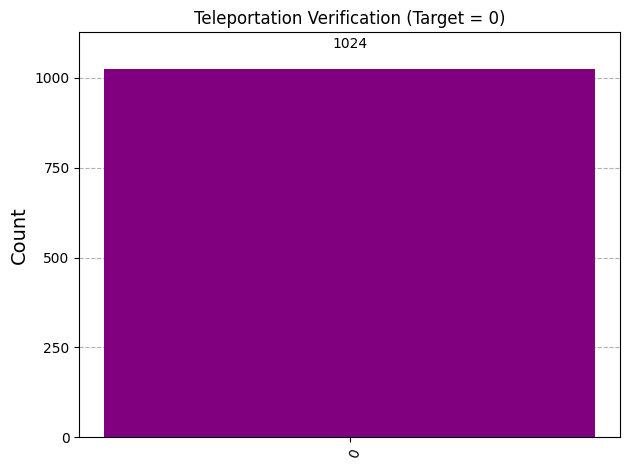

In [6]:
# 6. How do we prove it worked? 
# Bob applies the exact INVERSE of Alice's original rotation.
# If teleportation succeeded, Bob's qubit will perfectly un-rotate back to exactly |0>.
qc.rx(-np.pi/4, 2)
qc.measure(2, crb)

# Import the Aer Simulator and its V2 Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2

# Initialize the Aer-backed V2 Sampler (which supports dynamic control flow)
backend = AerSimulator()
sampler = SamplerV2()

# Execute the circuit
job = sampler.run([qc], shots=1024)
pub_result = job.result()[0]

# Extract the counts specifically from Bob's classical register
bob_counts = pub_result.data.bob_val.get_counts()

print(f"Bob's Verification Counts: {bob_counts}")
display(plot_histogram(bob_counts, title="Teleportation Verification (Target = 0)", color="purple"))